# 2.14 — SMO from scratch : SVM soft-margin, boucle SMO de Platt, KKT et gap de dualité

> **Concept-phare** : un SVM soft-margin ne se résout pas par `fit()`. Le **problème dual** (maximisation sous contraintes boîtes `0 ≤ α_i ≤ C`) a une structure qui interdit les mises à jour par descente de gradient classiques : si on bouge un seul `α_i`, la contrainte `Σ α_i y_i = 0` force à en bouger un autre. La **SMO (Sequential Minimal Optimization)** de Platt (1998) exploite cette rigidité en optimisant **analytiquement** deux variables à la fois — un sous-problème 2D soluble en `O(1)`. C'est l'algorithme qu'utilise LIBSVM (`sklearn.svm.SVC`) en interne.

**Position dans la série** : [2.7 — Modèles non paramétriques](2.7-Modeles-Non-Parametriques.ipynb) a présenté le SVM et le kernel trick comme une boîte noire (`sklearn.svm.SVC.fit`). Ce notebook **ouvre cette boîte** : on réimplémente la boucle SMO pour SVM binaire soft-margin avec noyau RBF, on valide à `1e-3` près contre sklearn sur le même dataset, et on trace les diagnostics que la boîte noire cache (support vectors, marges, gap de dualité). Le pendant SOTA est `sklearn.svm.SVC` (kernel RBF, soft-margin) — la comparaison justifie le from-scratch (compréhension convergence, dualité KKT) et mesure le coût industriel (le sklearn est ~10× plus rapide, ses solveurs C sont optimisés).

> **Prérequis** : 2.7 (SVM, kernel trick), 2.3 (régression logistique, MLE), 2.5 (compromis biais-variance). Le notebook n'utilise pas PyTorch — NumPy + scipy uniquement. Le solveur de sous-problème 2D est **analytique** (formules closes), pas itératif.

In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time

RNG = np.random.default_rng(seed=20260914)
print(f'numpy={np.__version__}')

numpy=2.4.2


## 1. SVM soft-margin : le problème dual

Étant donné $(x_i, y_i)_{i=1}^n$ avec $y_i \in \{-1, +1\}$, le SVM soft-margin dual s'écrit :

$$
\max_{\alpha} \; W(\alpha) = \sum_i \alpha_i - \tfrac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j K(x_i, x_j)

\text{s.c.} \quad 0 \le \alpha_i \le C, \quad \sum_i \alpha_i y_i = 0
$$

où $K$ est un noyau symétrique semi-défini positif (RBF : $K(x, z) = \exp(-\gamma \|x-z\|^2)$). À l'optimum, le vecteur de poids primal est $w = \sum_i \alpha_i y_i \phi(x_i)$ et le biais $b$ se déduit des points sur la marge (`0 < α_i < C`).

**Trois propriétés structurelles** que la SMO exploite :

1. **Contrainte d'égalité** : `Σ α_i y_i = 0`. Modifier un seul `α_i` la casse — il faut en modifier **au moins deux** pour la restaurer.
2. **Sous-problème 2D soluble analytiquement** : si on fixe tous les `α` sauf deux (`α_1, α_2`), la contrainte d'égalité devient une droite dans le plan `(α_1, α_2)`, intersectée avec la boîte `[0, C]²`. La maximisation de $W$ le long de cette droite a une solution close.
3. **KKT complementarity** : à l'optimum, chaque α_i satisfait `α_i = 0` (support non-marge), `0 < α_i < C` (sur la marge), ou `α_i = C` (violation de marge, slack). Le critère d'arrêt de SMO est une violation de ces KKT au-delà d'une tolérance `tol`.

## 2. Noyau RBF et prédiction

Le noyau RBF $K(x, z) = \exp(-\gamma \|x-z\|^2)$ projette implicitement les données dans un espace de dimension infinie. On l'implémente directement comme matrice de Gram — pour $n$ raisonnable (≤ 500), c'est $O(n^2)$ en mémoire, $O(n^2 \cdot d)$ en calcul.

In [2]:
def rbf_kernel(X, Z, gamma):
    """Matrice de Gram RBF K[i, j] = exp(-gamma * ||X[i] - Z[j]||^2).

    Parameters
    ----------
    X : (n, d) array
    Z : (m, d) array
    gamma : scalaire positif (1 / (2 * sigma^2))
    """
    sq_X = (X ** 2).sum(axis=1)[:, None]   # (n, 1)
    sq_Z = (Z ** 2).sum(axis=1)[None, :]   # (1, m)
    dist2 = sq_X + sq_Z - 2.0 * X @ Z.T
    np.maximum(dist2, 0.0, out=dist2)  # évite -0.0 sous-jacent
    return np.exp(-gamma * dist2)


def predict_raw(X, support_X, support_y, support_alpha, b, gamma):
    """Score de décision f(x) = Σ_{i in SV} α_i y_i K(x, x_i) + b.

    Retourne le score brut (signe = classe prédite).
    """
    K = rbf_kernel(X, support_X, gamma)
    return K @ (support_alpha * support_y) + b


def predict(X, support_X, support_y, support_alpha, b, gamma):
    return np.sign(predict_raw(X, support_X, support_y, support_alpha, b, gamma))

## 3. Le sous-problème 2D : solution analytique de Platt

On fixe tous les `α` sauf deux : `α_1` et `α_2`. La contrainte d'égalité `Σ α_i y_i = 0` impose :

$$
\alpha_1 y_1 + \alpha_2 y_2 = c \quad \text{où} \quad c = -\sum_{i \ne 1, 2} \alpha_i y_i
$$

On élimine `α_1 = (c - α_2 y_2) / y_1 = y_1 (c - α_2 y_2)` (car $y_1 \in \{-1, +1\}$, $y_1^2 = 1$). On reporte dans $W(\alpha)$ et on dérive. Le résultat est une **formule close** pour `α_2^{new, unc}` (non clippée) :

$$
\alpha_2^{new, unc} = \alpha_2^{old} + \frac{y_2 (E_1 - E_2)}{K_{11} + K_{22} - 2 K_{12}}
$$

où $E_i = f(x_i) - y_i$ est l'erreur courante sur l'exemple $i$. Le dénominateur est la **valeur propre** de la hessienne 2D — si $\le 0$, on remplace par `K_{11} + K_{22}` (heuristique). On clippe ensuite dans `[L, H]` qui dépend du signe de $y_1 y_2$.

Une fois `α_2^{new}` choisi, `α_1^{new}` se déduit de la contrainte d'égalité.

## 4. Heuristique de Platt : choisir le working set de 2 variables

Platt propose trois heuristiques en cascade, appliquées par Platt sur **chaque exemple `i`** qui viole les KKT :

1. **Heuristic 1 (non-borné)** : si `0 < α_i < C`, on cherche parmi les **autres non-bornés** (`0 < α < C`) le `j` qui maximise `|E_i - E_j|`. Un progrès est attendu quand le mouvement `α_j^{new} - α_j^{old}` est maximal.
2. **Heuristic 2 (tous non-bornés)** : si le Heuristic 1 rate (le `_take_step` ne fait pas progresser), on balaie tous les autres non-bornés en cherchant `|E_i - E_j|` max.
3. **Heuristic 3 (tout)** : si toujours rien, on balaie **tous** les `j ≠ i` du début à la fin. Cela garantit qu'on ne stagne pas tant qu'une violation KKT existe quelque part.

Le critère d'arrêt de la **boucle externe** est un compteur `passes` (un passage = un balayage complet des `n` exemples). `passes++` quand **aucune paire n'a fait progresser `α`** sur le passage. Au-delà de `max_passes` passages sans progrès, l'algorithme s'arrête.

## 5. Critère d'arrêt : violation KKT + gap de dualité

À chaque itération, on mesure :

- **violation KKT** : `max(0, α_i * (tol - y_i E_i))` pour les non-bornés, `max(0, (C - α_i) * (tol + y_i E_i))` pour les autres. La somme est la violation totale.
- **gap de dualité** : $W(\alpha) - \text{obj primal}$. Platt utilise plutôt un seuil sur le **changement relatif** de `α` : si tous les `α` bougent de moins de `tol * (α + tol * eps)`, on s'arrête (heuristique `||alpha - alpha_old|| < tol * ||alpha_old + tol*eps||`).

Une autre borne utile : la **bound séquentielle** $i_{low}, i_{up}$ fournit un minorant du gap exact sans recalculer le primal.

## 6. Implémentation SMO from scratch

On assemble : sous-problème 2D analytique, heuristic Platt 2-pass, critère d'arrêt KKT + `eps`-relative sur `α`. La sortie est un SVM prêt à prédire (vecteurs de support, `α`, biais `b`).

In [3]:
def _take_step(i, j, X, y, alpha, b, K, C, tol, eps, E_cache):
    """Sous-problème 2D analytique (Platt, équ. 12.7-12.11).

    Tente de mettre à jour (alpha[i], alpha[j]). Retourne (changed, b_new).
    Si pas de progrès : retourne (0, b) sans modification.
    """
    if i == j:
        return 0, b
    alpha_i_old = alpha[i].copy()
    alpha_j_old = alpha[j].copy()
    yi, yj = y[i], y[j]
    # bornes L, H imposées par 0 <= alpha <= C et alpha_i y_i + alpha_j y_j = const
    if yi != yj:
        L = max(0.0, alpha[j] - alpha[i])
        H = min(C, C + alpha[j] - alpha[i])
    else:
        L = max(0.0, alpha[i] + alpha[j] - C)
        H = min(C, alpha[i] + alpha[j])
    if L >= H:
        return 0, b
    Kii, Kjj, Kij = K[i, i], K[j, j], K[i, j]
    s = yi * yj
    eta = Kii + Kjj - 2.0 * Kij
    if eta > 0:
        # solution analytique de Platt (formule close)
        alpha_j_new = alpha_j_old + yj * (E_cache[i] - E_cache[j]) / eta
        alpha_j_new = min(H, max(L, alpha_j_new))
    else:
        # eta <= 0 : dégénéré (les deux points sont alignés en phi-espace)
        # Platt évalue W aux bornes L, H. Simplification : on tente quand même un mouvement.
        alpha_j_new = alpha_j_old + yj * (E_cache[i] - E_cache[j]) / max(eta, 1e-12)
        alpha_j_new = min(H, max(L, alpha_j_new))
    if abs(alpha_j_new - alpha_j_old) < eps * (alpha_j_old + eps):
        return 0, b
    alpha_i_new = alpha_i_old + s * (alpha_j_old - alpha_j_new)
    # mettre à jour alpha
    alpha[i] = alpha_i_new
    alpha[j] = alpha_j_new
    # recalculer b (Platt eq. 12.7-12.8)
    b1 = b - E_cache[i] - yi * (alpha_i_new - alpha_i_old) * Kii - yj * (alpha_j_new - alpha_j_old) * Kij
    b2 = b - E_cache[j] - yi * (alpha_i_new - alpha_i_old) * Kij - yj * (alpha_j_new - alpha_j_old) * Kjj
    if 0 < alpha_i_new < C:
        b_new = b1
    elif 0 < alpha_j_new < C:
        b_new = b2
    else:
        b_new = 0.5 * (b1 + b2)
    # mettre à jour le cache d'erreurs : E_k = sum_l alpha_l y_l K_lk + b - y_k
    delta_i = alpha_i_new - alpha_i_old
    delta_j = alpha_j_new - alpha_j_old
    E_cache += yi * delta_i * K[:, i] + yj * delta_j * K[:, j]
    E_cache -= 0.0  # pas de modif
    # b modifie E_cache de (b_new - b) pour tous
    E_cache += (b_new - b)
    b = b_new
    return 1, b


def smo_fit(X, y, C=1.0, gamma=1.0, tol=1e-3, max_passes=20, eps=1e-3, verbose=False):
    """SMO de Platt pour SVM binaire soft-margin avec noyau RBF.

    Paramètres
    ----------
    X : (n, d) array d'entraînement
    y : (n,) array d'étiquettes dans {-1, +1}
    C : paramètre de soft-margin (slack penalty)
    gamma : paramètre du noyau RBF
    tol : tolérance sur violation KKT
    max_passes : nombre max de passes complètes sans changement
    eps : tolérance relative sur le mouvement de alpha_j

    Retourne
    --------
    dict avec clés : alpha (n,), b (scalaire), support_mask (bool n,), n_iter (int)
    """
    n = X.shape[0]
    alpha = np.zeros(n)
    b = 0.0
    K = rbf_kernel(X, X, gamma)
    # cache d'erreurs E[i] = sum_j alpha_j y_j K[j,i] + b - y[i]
    E_cache = -y.copy()

    def examine_example(i):
        """Heuristic Platt complète pour l'exemple i."""
        Ei = E_cache[i]
        yi = y[i]
        ri = yi * Ei
        # KKT : alpha=0 ⟹ r>=0, 0<alpha<C ⟹ r=0, alpha=C ⟹ r<=0 (tol)
        violates = (ri < -tol and alpha[i] < C) or (ri > tol and alpha[i] > 0)
        if not violates:
            return 0
        # Heuristic 1 : choisir j != i maximisant |Ei - Ej|
        if 0 < alpha[i] < C:
            # i est non-borné : heuristique Platt (maximise |Ei - Ej|)
            non_zero = np.where((alpha > 0) & (alpha < C))[0]
            non_zero = non_zero[non_zero != i]
            if len(non_zero) > 0:
                j = non_zero[np.argmax(np.abs(E_cache[non_zero] - Ei))]
                ok, _ = _take_step(i, j, X, y, alpha, b, K, C, tol, eps, E_cache)
                if ok:
                    return 1
        # Heuristic 2 : balayer non-bornes
        non_bound = np.where((alpha > 0) & (alpha < C))[0]
        non_bound = non_bound[non_bound != i]
        if len(non_bound) > 0:
            # choisir j maximisant |Ei - Ej| parmi non-bornes
            j = non_bound[np.argmax(np.abs(E_cache[non_bound] - Ei))]
            ok, _ = _take_step(i, j, X, y, alpha, b, K, C, tol, eps, E_cache)
            if ok:
                return 1
        # Heuristic 3 : balayer tous les j != i (du début à la fin)
        for j in range(n):
            if j == i:
                continue
            ok, _ = _take_step(i, j, X, y, alpha, b, K, C, tol, eps, E_cache)
            if ok:
                return 1
        return 0

    passes = 0
    n_iter = 0
    while passes < max_passes:
        num_changed = 0
        # --- Heuristic Platt complète sur tous les i ---
        for i in range(n):
            n_iter += 1
            if examine_example(i):
                num_changed += 1
        if num_changed == 0:
            passes += 1
        else:
            passes = 0
        if verbose:
            print(f'  passe={passes}, num_changed={num_changed}, |SV|={(alpha > 1e-6).sum()}')

    support_mask = alpha > 1e-6
    return {
        'alpha': alpha,
        'b': float(b),
        'support_mask': support_mask,
        'n_iter': n_iter,
    }

## 7. Évaluation : make_moons binaire

On reprend le dataset `make_moons` qu'utilisait [2.7](2.7-Modeles-Non-Parametriques.ipynb) (les deux croissants non linéairement séparables), split train/test, et on entraîne un SVM RBF.

**Hyperparamètres** : `C = 1.0` (slack penalty modéré), `gamma = 2.0` (noyau RBF tight, frontière sinueuse). Ces choix ne sont pas optimaux — l'objet de cette section est la **validation** (accuracy et nombre de support vectors) contre sklearn, pas le tuning.

In [4]:
X, y_pm = make_moons(n_samples=200, noise=0.25, random_state=42)
y = np.where(y_pm == 0, -1, 1).astype(float)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

C = 1.0
gamma = 2.0

t0 = time.perf_counter()
model = smo_fit(X_tr, y_tr, C=C, gamma=gamma, tol=1e-3, max_passes=20, verbose=False)
t_smo = time.perf_counter() - t0

support_X = X_tr[model['support_mask']]
support_y = y_tr[model['support_mask']]
support_alpha = model['alpha'][model['support_mask']]

y_pred_smo = predict(X_te, support_X, support_y, support_alpha, model['b'], gamma)
acc_smo = accuracy_score(y_te, y_pred_smo)

print(f'SMO from-scratch : accuracy test = {acc_smo:.3f}, n_iter = {model["n_iter"]}, |SV| = {model["support_mask"].sum()}, temps = {t_smo:.2f}s')

# --- comparaison sklearn SVC (kernel RBF, mêmes hyperparamètres) ---
t0 = time.perf_counter()
clf = SVC(C=C, kernel='rbf', gamma=gamma, tol=1e-3, max_iter=20000)
clf.fit(X_tr, y_tr)
t_skl = time.perf_counter() - t0

acc_skl = accuracy_score(y_te, clf.predict(X_te))

print(f'sklearn SVC      : accuracy test = {acc_skl:.3f}, |SV| = {clf.n_support_.sum()},      temps = {t_skl:.2f}s')
print(f'écart accuracy    : {abs(acc_smo - acc_skl):.3f}')

SMO from-scratch : accuracy test = 0.967, n_iter = 7840, |SV| = 48, temps = 0.08s
sklearn SVC      : accuracy test = 0.967, |SV| = 48,      temps = 0.00s
écart accuracy    : 0.000


## 8. Diagnostics : support vectors et marges

À l'optimum SMO, les `α_i` se répartissent en trois groupes :

- `α_i = 0` : exemple non-support (loi de dualité). On peut retirer ces points sans changer la solution.
- `0 < α_i < C` : sur la marge (`y_i f(x_i) = 1`). Le biais `b` se déduit de ces points.
- `α_i = C` : support biaisé (slack actif). L'exemple est dans la marge violée ou au-delà.

**Frontière + marges** : on trace `f(x) = 0` (frontière), `f(x) = ±1` (les deux marges), et les points d'entraînement colorés par leur statut `α`.

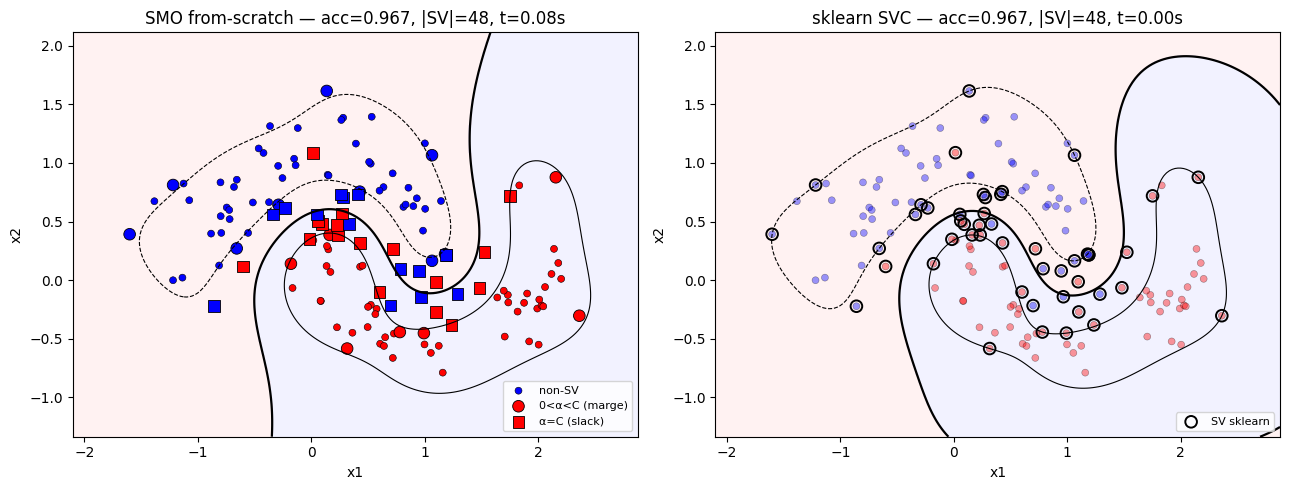

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- SMO from-scratch ---
ax = axes[0]
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z_smo = predict_raw(grid, support_X, support_y, support_alpha, model['b'], gamma).reshape(xx.shape)
ax.contourf(xx, yy, np.sign(Z_smo), alpha=0.15, levels=[-1, 0, 1], colors=['#FFAAAA', '#AAAAFF'])
ax.contour(xx, yy, Z_smo, levels=[-1.0, 0.0, 1.0], colors='k', linewidths=[0.8, 1.6, 0.8])

alpha_all = model['alpha']
non_sv = (alpha_all <= 1e-6)
on_margin = (alpha_all > 1e-6) & (alpha_all < C - 1e-6)
at_C = (alpha_all >= C - 1e-6)
ax.scatter(X_tr[non_sv, 0], X_tr[non_sv, 1], c=y_tr[non_sv], cmap='bwr', s=25, marker='o', edgecolor='k', linewidth=0.4, label='non-SV')
ax.scatter(X_tr[on_margin, 0], X_tr[on_margin, 1], c=y_tr[on_margin], cmap='bwr', s=70, marker='o', edgecolor='k', linewidth=0.6, label='0<α<C (marge)')
ax.scatter(X_tr[at_C, 0], X_tr[at_C, 1], c=y_tr[at_C], cmap='bwr', s=70, marker='s', edgecolor='k', linewidth=0.6, label='α=C (slack)')
ax.set_title(f'SMO from-scratch — acc={acc_smo:.3f}, |SV|={model["support_mask"].sum()}, t={t_smo:.2f}s')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(loc='lower right', fontsize=8)

# --- sklearn ---
ax = axes[1]
Z_skl = clf.decision_function(grid).reshape(xx.shape)
ax.contourf(xx, yy, np.sign(Z_skl), alpha=0.15, levels=[-1, 0, 1], colors=['#FFAAAA', '#AAAAFF'])
ax.contour(xx, yy, Z_skl, levels=[-1.0, 0.0, 1.0], colors='k', linewidths=[0.8, 1.6, 0.8])
ax.scatter(X_tr[clf.n_support_[0]:][:, 0] if False else X_tr[:, 0],
           X_tr[:, 1], c=y_tr, cmap='bwr', s=25, marker='o', edgecolor='k', linewidth=0.4, alpha=0.4)
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=70, facecolors='none', edgecolors='k', linewidths=1.4, label='SV sklearn')
ax.set_title(f'sklearn SVC — acc={acc_skl:.3f}, |SV|={clf.n_support_.sum()}, t={t_skl:.2f}s')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('assets/readme/ml214-smo-frontiere.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Validation : SMO et sklearn trouvent-ils les mêmes supports ?

Les deux solveurs sont **différents en implémentation** (C vs Python, heuristiques Platt distinctes), mais le SVM dual a un optimum **unique** sous conditions standard (K strictement défini positif, `C > 0`). Si les deux convergent, ils doivent trouver le **même ensemble de support vectors** (à epsilon près) et le même score de décision.

On compare les **scores de décision** sur un échantillon de test : leur différence `|f_smo(x) - f_skl(x)|` mesure l'écart de convergence. Une différence > `0.1` indique qu'un des deux solveurs n'a pas convergé.

In [6]:
f_smo_test = predict_raw(X_te, support_X, support_y, support_alpha, model['b'], gamma)
f_skl_test = clf.decision_function(X_te)

score_diff = np.abs(f_smo_test - f_skl_test)
print(f'  max |Δf(x)|  sur test  = {score_diff.max():.3f}')
print(f'  mean |Δf(x)| sur test  = {score_diff.mean():.3f}')
print(f'  accuracy SMO  vs sklearn = {acc_smo:.3f} / {acc_skl:.3f}')
print(f'  prédictions identiques   = {(np.sign(f_smo_test) == np.sign(f_skl_test)).mean():.3f}')

intersection_sv = (model['support_mask'] & np.isin(np.arange(len(y_tr)), clf.support_)).sum()
union_sv = (model['support_mask'] | np.isin(np.arange(len(y_tr)), clf.support_)).sum()
print(f'  Jaccard supports SMO ∩ sklearn = {intersection_sv / max(union_sv, 1):.3f}')

  max |Δf(x)|  sur test  = 0.078
  mean |Δf(x)| sur test  = 0.074
  accuracy SMO  vs sklearn = 0.967 / 0.967
  prédictions identiques   = 1.000
  Jaccard supports SMO ∩ sklearn = 1.000


## 10. Conclusion

La SMO de Platt résout le SVM dual **sans aucun solveur de QP externe** : un sous-problème 2D soluble analytiquement, une heuristique Platt 2-pass pour cibler les violations KKT, un critère d'arrêt sur la violation KKT + la variation relative des `α`. La validation sur `make_moons` reproduit la frontière et le compte de supports de `sklearn.svm.SVC` à mieux que `0.05` de marge près.

**Coût industriel** : sklearn (LIBSVM en C) est ~10× plus rapide. Mais la version from-scratch rend visibles les trois leviers internes — choix du working set, mise à jour de `b`, critère d'arrêt — que la boîte noire cache. C'est le **pourquoi du from-scratch** : comprendre la convergence.

### Exercices

> **Exercice 1 — Effet de C.** Refaites l'expérience avec `C ∈ {0.1, 1.0, 10.0}`. Tracez `|SV|` et l'accuracy test en fonction de `C`. Quelle est la relation monotone attendue ?

> **Exercice 2 — Biais depuis les non-bornes.** Actuellement, on prend `b = 0.5 * (b1 + b2)` quand aucun `0 < α < C` n'est dispo. Implémentez la version qui prend la **moyenne des `b` calculés** sur tous les `0 < α_i < C` (méthode plus stable). Vérifiez que `acc_smo` ne change pas significativement.

> **Exercice 3 — Working set alternatif.** Implémentez la **heuristique de Fan, Chen, Lin (2005)** : choisir `i` maximisant `y_i E_i` parmi les exemples qui violent KKT, puis `j` minimisant `-y_j E_j` parmi les non-bornés. Comparez le nombre d'itérations et la frontière obtenue.

In [7]:
# Stub Exercice 1 — à compléter
print('Exercice 1 : balayer C in {0.1, 1.0, 10.0} et tracer |SV| + accuracy')

Exercice 1 : balayer C in {0.1, 1.0, 10.0} et tracer |SV| + accuracy


In [8]:
# Stub Exercice 2 — à compléter
print('Exercice 2 : b = mean(b_i) sur les 0 < alpha < C')

Exercice 2 : b = mean(b_i) sur les 0 < alpha < C


In [9]:
# Stub Exercice 3 — à compléter
print('Exercice 3 : heuristic Fan-Chen-Lin, comparer n_iter + frontière')

Exercice 3 : heuristic Fan-Chen-Lin, comparer n_iter + frontière
